## Run INSPIRE on the human DLPFC dataset (12 sections)

The spatial transcriptomics DLPFC data are publicly available at https://github.com/LieberInstitute/spatialLIBD.

### Import packages

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

import INSPIRE

import warnings
warnings.filterwarnings("ignore")

### Load data

In [2]:
data_dir = "data/DLPFC/spatialLIBD"

slice_idx_list = [151673, 151674, 151675, 151676,
                  151507, 151508, 151509, 151510,
                  151672, 151671, 151670, 151669]
adata_st_list = []

for slice_idx in slice_idx_list:
    adata_st = sc.read_visium(path=data_dir+"/%d" % slice_idx, count_file="%d_filtered_feature_bc_matrix.h5" % slice_idx)
    anno_df = pd.read_csv(data_dir+'/barcode_level_layer_map.tsv', sep='\t', header=None)
    anno_df = anno_df.iloc[anno_df[1].values.astype(str) == str(slice_idx)]
    anno_df.columns = ["barcode", "slice_id", "layer"]
    anno_df.index = anno_df['barcode']
    adata_st.obs = adata_st.obs.join(anno_df, how="left")
    adata_st = adata_st[adata_st.obs['layer'].notna()]
    adata_st_add = adata_st.copy()
    adata_st_add.var_names_make_unique()
    adata_st_list.append(adata_st_add)

Finding highly variable genes...
shape of adata 0 before quality control:  (3611, 33525)
shape of adata 0 after quality control:  (3611, 13067)
shape of adata 1 before quality control:  (3635, 33525)
shape of adata 1 after quality control:  (3635, 13955)
shape of adata 2 before quality control:  (3566, 33525)
shape of adata 2 after quality control:  (3566, 12430)
shape of adata 3 before quality control:  (3431, 33525)
shape of adata 3 after quality control:  (3431, 12564)
shape of adata 4 before quality control:  (4221, 33525)
shape of adata 4 after quality control:  (4220, 11963)
shape of adata 5 before quality control:  (4381, 33525)
shape of adata 5 after quality control:  (4380, 11437)
shape of adata 6 before quality control:  (4788, 33525)
shape of adata 6 after quality control:  (4786, 12394)
shape of adata 7 before quality control:  (4595, 33525)
shape of adata 7 after quality control:  (4593, 12066)
shape of adata 8 before quality control:  (3888, 33525)
shape of adata 8 after 

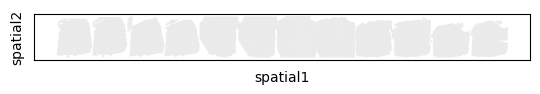

Store counts and library sizes for Poisson modeling...
Normalize data...


In [3]:
adata_st_list, adata_full = INSPIRE.utils.preprocess(adata_st_list=adata_st_list,
                                                     num_hvgs=10000,
                                                     min_genes_qc=50,
                                                     min_cells_qc=50,
                                                     spot_size=100)

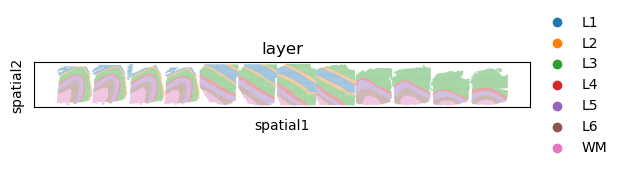

In [4]:
sc.pl.spatial(adata_full, color="layer", spot_size=100)

In [5]:
adata_st_list = INSPIRE.utils.build_graph_GAT(adata_st_list=adata_st_list,
                                              rad_coef=1.1)

Start building graphs...
Calculate radius cutoff based on 'rad_coef' and mininal distance between spots/cells within a dataset...
Radius for graph connection is 150.7000.
Build graphs for GAT networks
5.8261 neighbors per cell on average.
5.8140 neighbors per cell on average.
5.8015 neighbors per cell on average.
5.8193 neighbors per cell on average.
5.8649 neighbors per cell on average.
5.8630 neighbors per cell on average.
5.8801 neighbors per cell on average.
5.8720 neighbors per cell on average.
5.8565 neighbors per cell on average.
5.8563 neighbors per cell on average.
5.8381 neighbors per cell on average.
5.8102 neighbors per cell on average.


### Run INSPIRE model

In [6]:
model = INSPIRE.model.Model_GAT(adata_st_list=adata_st_list,
                                n_spatial_factors=20,
                                n_training_steps=10000,
                                use_margin=False,
                               )

In [7]:
model.train()

  0%|          | 1/10000 [00:00<1:35:10,  1.75it/s]

Step: 0, d_loss: 15.3705, Loss: 22808.4746, recon_loss: 19677.8652, fe_loss: 479.7892, geom_loss: 6710.6357, beta_loss: 250.1640, gan_loss: 7.4837


  5%|▌         | 501/10000 [02:39<50:24,  3.14it/s]

Step: 500, d_loss: 8.4142, Loss: 18688.6230, recon_loss: 15708.3359, fe_loss: 341.2279, geom_loss: 2015.9548, beta_loss: 255.3434, gan_loss: 22.6528


 10%|█         | 1001/10000 [05:18<47:51,  3.13it/s]

...

 90%|█████████ | 9001/10000 [47:34<05:14,  3.18it/s]

Step: 9000, d_loss: 6.1647, Loss: 11766.7998, recon_loss: 8900.0635, fe_loss: 336.2672, geom_loss: 3778.1899, beta_loss: 239.7764, gan_loss: 28.5707


 95%|█████████▌| 9501/10000 [50:12<02:36,  3.18it/s]

Step: 9500, d_loss: 5.9088, Loss: 11760.2031, recon_loss: 8895.9180, fe_loss: 336.1664, geom_loss: 3829.1467, beta_loss: 239.7111, gan_loss: 27.2128


100%|██████████| 10000/10000 [52:50<00:00,  3.15it/s]


In [8]:
adata_full, basis_df = model.eval(adata_full)
basis = np.array(basis_df.values)

Add cell/spot proportions of spatial factors into adata_full.obs...
Add cell/spot latent representations into adata_full.obsm['latent']...


### Spatial distributions of spatial factors in tissues

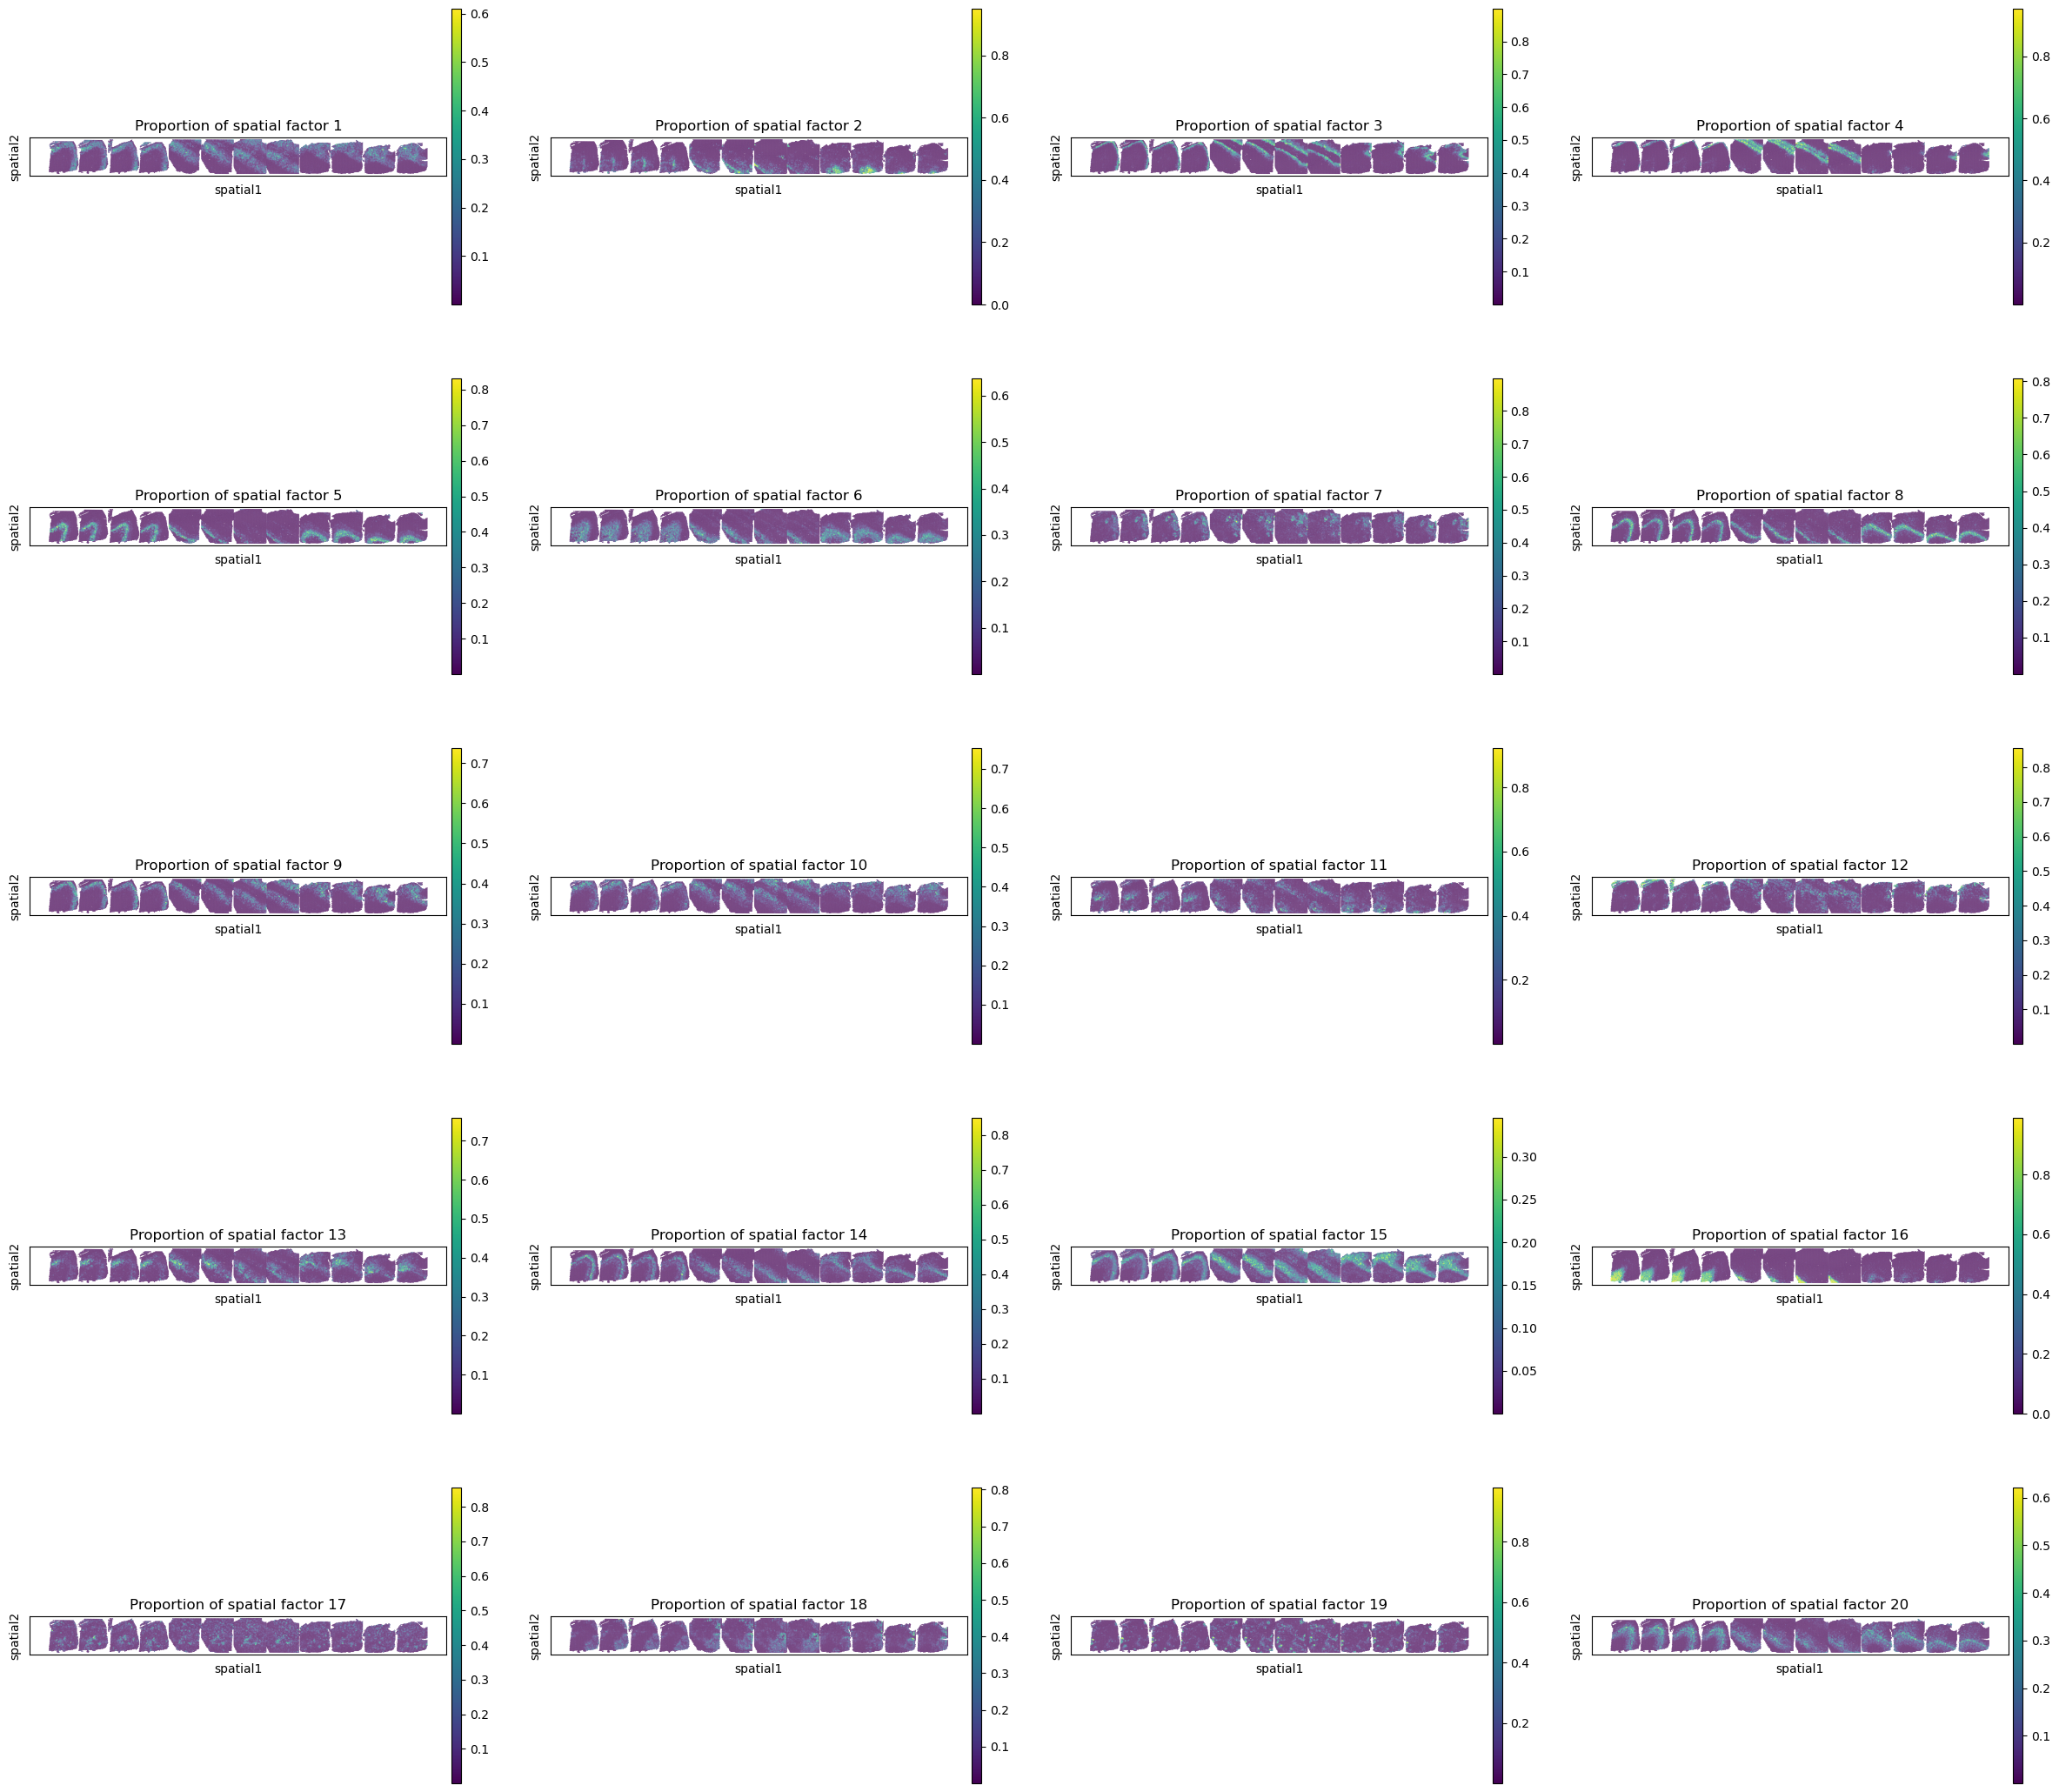

In [9]:
sc.pl.spatial(adata_full, color=["Proportion of spatial factor "+str(i+1) for i in range(20)], spot_size=150.)

### Spot representations and spatial domain identification

In [10]:
# calculate 2D UMAP coordinate of spots based on INSPIRE's learned spot representations.
reducer = umap.UMAP(n_neighbors=50,
                    n_components=2,
                    metric="euclidean",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['latent'])
adata_full.obsm["X_umap"] = embedding
adata_full.obs["slice"] = adata_full.obs["slice"].values.astype(str)

UMAP(local_connectivity=1, min_dist=0.3, n_neighbors=50, random_state=1234, repulsion_strength=1, verbose=True)
Wed May 27 16:16:29 2026 Construct fuzzy simplicial set
Wed May 27 16:16:29 2026 Finding Nearest Neighbors
Wed May 27 16:16:29 2026 Building RP forest with 16 trees
Wed May 27 16:16:32 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Wed May 27 16:16:45 2026 Finished Nearest Neighbor Search
Wed May 27 16:16:48 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed May 27 16:17:40 2026 Finished embedding


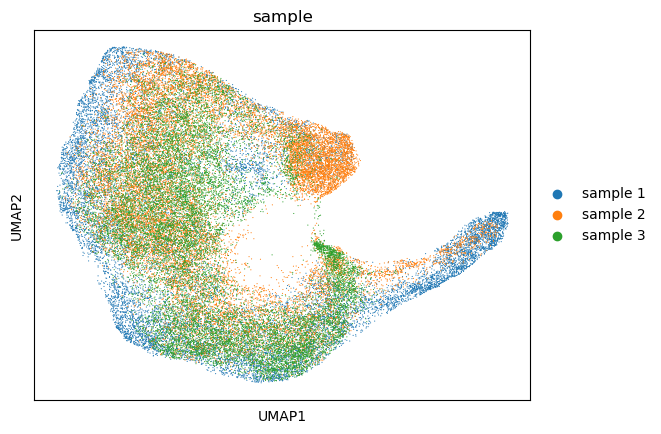

In [11]:
adata_full.obs["sample"] = ""
adata_full.obs["sample"][adata_full.obs["slice_id"].isin([151673.0, 151674.0, 151675.0, 151676.0])] = "sample 1"
adata_full.obs["sample"][adata_full.obs["slice_id"].isin([151507.0, 151508.0, 151509.0, 151510.0])] = "sample 2"
adata_full.obs["sample"][adata_full.obs["slice_id"].isin([151669.0, 151670.0, 151671.0, 151672.0])] = "sample 3"
sc.pl.umap(adata_full, color=["sample"])

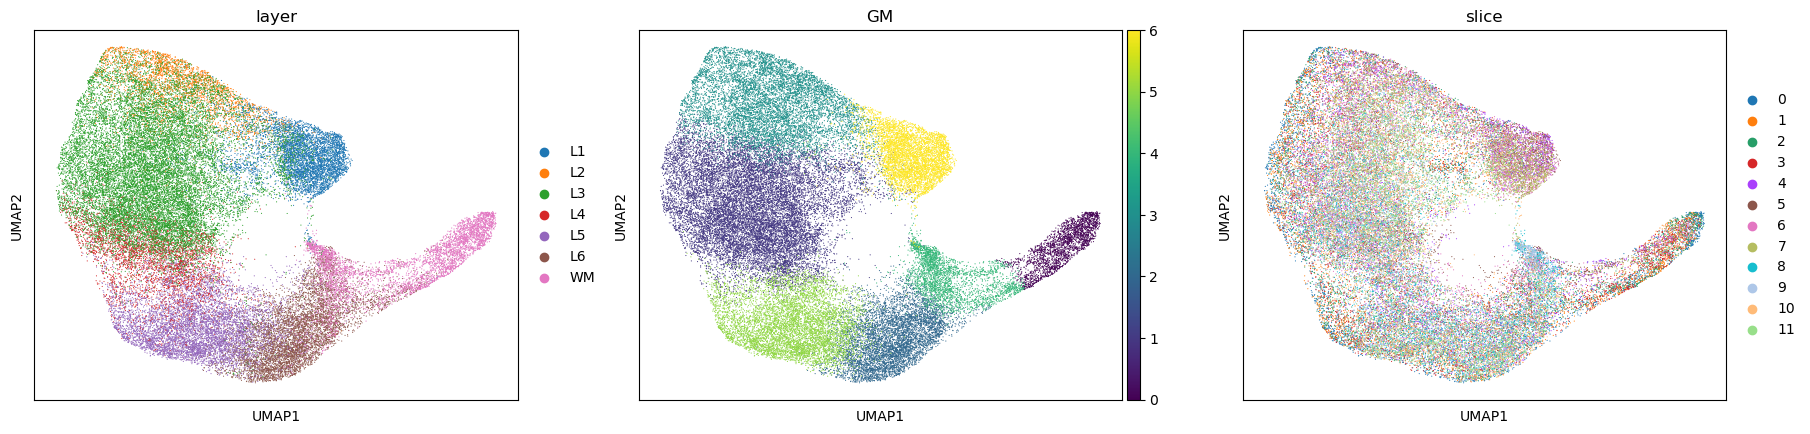

In [12]:
# perform clustering on spot representations (spatial domain identification)
from sklearn.mixture import GaussianMixture
np.random.seed(12)
gm = GaussianMixture(n_components=7, covariance_type='tied', init_params='kmeans')
# gm = GaussianMixture(n_components=7, covariance_type='spherical', init_params='kmeans')
y = gm.fit_predict(adata_full.obsm['latent'], y=None)
adata_full.obs["GM"] = y
sc.pl.umap(adata_full, color=["layer", "GM", "slice"])

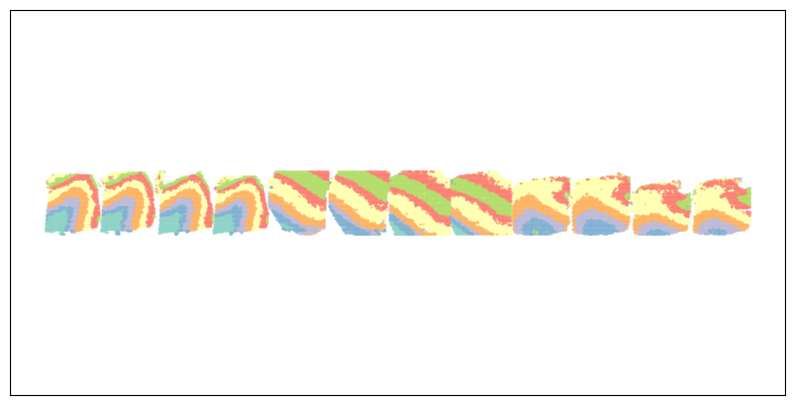

In [13]:
colors = [i for i in get_cmap('Set3').colors]
size = .1
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(1,1,1)
ax.axis('equal')
for i in range(len(set(adata_full.obs["GM"]))):
    ax.scatter(adata_full.obsm["spatial"][adata_full.obs["GM"].values.astype(str)==str(i), 0],
               -adata_full.obsm["spatial"][adata_full.obs["GM"].values.astype(str)==str(i), 1],
               s=size, color=colors[i], label="cluster "+str(i))
ax.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
plt.show()

In [14]:
n_slices = len(set(adata_full.obs.slice.values))

### Spot representation scores

In [15]:
# ASW
for i in range(n_slices):
    adata_tmp = adata_full[adata_full.obs.slice.values.astype(str) == str(i), :]
    ASW = INSPIRE.utils.calculate_ASW(adata_tmp.obsm["latent"], adata_tmp.obs["layer"].astype(str))
    print("slice", str(i), "ASW =", ASW)

slice 0 ASW = 0.23197548
slice 1 ASW = 0.24192268
slice 2 ASW = 0.22492354
slice 3 ASW = 0.2216665
slice 4 ASW = 0.18352832
slice 5 ASW = 0.15420167
slice 6 ASW = 0.1761681
slice 7 ASW = 0.17795514
slice 8 ASW = 0.15332146
slice 9 ASW = 0.15149578
slice 10 ASW = 0.06571517
slice 11 ASW = 0.11021188


In [16]:
# ARI
for i in range(n_slices):
    adata_tmp = adata_full[adata_full.obs.slice.values.astype(str) == str(i), :]
    ARI = INSPIRE.utils.calculate_ARI(adata_tmp.obs["layer"].astype(str), adata_tmp.obs["GM"])
    print("slice", str(i), "ARI =", ARI)

slice 0 ARI = 0.5600348091339422
slice 1 ARI = 0.5468529614240895
slice 2 ARI = 0.5137500197821184
slice 3 ARI = 0.5181052446433895
slice 4 ARI = 0.548919916550783
slice 5 ARI = 0.5232734993786468
slice 6 ARI = 0.5442013715152354
slice 7 ARI = 0.5540827274679454
slice 8 ARI = 0.6090622409395503
slice 9 ARI = 0.61829991925835
slice 10 ARI = 0.38298653498501634
slice 11 ARI = 0.40187290374221163


In [17]:
# NMI
for i in range(n_slices):
    adata_tmp = adata_full[adata_full.obs.slice.values.astype(str) == str(i), :]
    NMI = INSPIRE.utils.calculate_NMI(adata_tmp.obs["layer"].astype(str), adata_tmp.obs["GM"])
    print("slice", str(i), "NMI =", NMI)

slice 0 NMI = 0.6769302842353887
slice 1 NMI = 0.6733260310174889
slice 2 NMI = 0.6561158880430559
slice 3 NMI = 0.6549891027415284
slice 4 NMI = 0.6807751961993169
slice 5 NMI = 0.6545039696759388
slice 6 NMI = 0.6595679645196831
slice 7 NMI = 0.652333342869043
slice 8 NMI = 0.6715646717474638
slice 9 NMI = 0.6774578435076237
slice 10 NMI = 0.5338836138723728
slice 11 NMI = 0.5651163172925143


### Factor scores

In [18]:
basis = np.array(basis_df.values)

In [19]:
# factor diversity
factor_diversity = INSPIRE.utils.calculate_factor_diversity(basis, n_top_genes=10)
print("factor_diversity =", factor_diversity)

factor_diversity = 0.385


In [20]:
adata_raw = adata_full[:, basis_df.columns]

# factor coherence
factor_coherence = INSPIRE.utils.calculate_factor_coherence(basis, n_top_genes=10, gene_counts=np.array(adata_raw.X.todense()))
print("factor_coherence =", factor_coherence)

factor_coherence = 0.11233645447205719
